# Notebook22 — Experimental Outcome Simulator for Engineered CHO Clones

## Purpose

Notebook21 estimated engineering risk, success probability, and expected net benefit for each proposed intervention.

Notebook22 moves one step closer to real experimental behavior.

Instead of asking:

**What is the expected engineering benefit?**

we now ask:

**What could we observe after running the engineering experiment?**

This notebook simulates post-engineering experimental outcomes using scientist-facing metrics:

- titer
- specific productivity, qP
- stability
- quality
- engineering ROI

## Core Concept

Real engineering outcomes are uncertain.

An intervention may:

- succeed strongly
- partially succeed
- fail
- create a negative tradeoff

Notebook22 converts risk-adjusted engineering recommendations into simulated experimental observations.

## Expected Output

By the end of this notebook, we will generate:

- before/after titer estimates
- before/after qP estimates
- before/after stability estimates
- before/after quality estimates
- observed engineering gains
- outcome categories
- top successful engineering projects
- experimental outcome datasets for Notebook23

## Section 1 — Load Notebook21 engineering risk dataset

Notebook21 produced the engineering risk assessment table.

This table contains:

- clone scores
- recommended intervention
- expected engineering gain
- success probability
- off-target risk
- engineering complexity
- realized gain

Notebook22 uses this file as the starting point for simulated experimental outcomes.

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]

engineering = pd.read_csv(
    ROOT /
    "data/synthetic/digital_twin/" /
    "notebook21_engineering_risk_assessment_5000_legacy.csv"
)

print("Engineering dataset shape:", engineering.shape)
display(engineering.head())

Engineering dataset shape: (36, 20)


,clone_id,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,decision,bottleneck,recommended_intervention,post_engineering_score,engineering_gain,success_probability,off_target_risk,engineering_complexity,engineering_success,realized_gain,engineering_confidence,expected_net_benefit,portfolio_group
0,CLONE_4625,59.323924,100.000000,69.850174,83.065313,17.302240,58.422895,Advance,omics,PDI_folding_support,75.317352,15.993428,0.75,0.20,0.45,True,15.993428,0.330,11.995071,Other
1,CLONE_4878,51.055084,79.679015,66.381308,69.204240,11.833808,63.761372,Advance,omics,PDI_folding_support,65.778556,14.723471,0.75,0.20,0.45,False,-3.698005,0.330,11.042604,Other
2,CLONE_3895,42.862936,1.170372,98.964170,82.267468,28.517580,79.479074,Advance,productivity,XBP1s_secretory_support,60.658313,17.795377,0.80,0.15,0.40,True,17.795377,0.408,14.236302,High Gain / Low Risk
3,CLONE_3895,42.631425,1.170372,98.607662,82.267468,28.517580,78.902602,Advance with Monitoring,productivity,XBP1s_secretory_support,62.177485,19.546060,0.80,0.15,0.40,True,19.546060,0.408,15.636848,High Gain / Low Risk
4,CLONE_3895,42.595722,1.170372,98.964170,82.267468,26.736152,79.479074,Advance with Monitoring,productivity,XBP1s_secretory_support,58.627415,16.031693,0.80,0.15,0.40,True,16.031693,0.408,12.825355,High Gain / Low Risk


## Section 2 — Inspect available engineering columns

Before simulation, we confirm the available columns.

This helps ensure that Notebook22 is aligned with the exported Notebook21 schema.

In [23]:
display(pd.DataFrame({"columns": engineering.columns}))

,columns
0,clone_id
1,overall_score
2,score_productivity
3,score_quality
4,score_stability
5,omics_score
6,rl_robustness_score
7,decision
8,bottleneck
9,recommended_intervention


## Section 3 — Create baseline experimental metrics

The previous notebooks mainly used normalized scores.

However, CLD scientists and CDMO teams usually interpret results using experimental units.

This section converts clone scores into approximate experimental metrics:

- titer in g/L
- qP in pg/cell/day
- stability in %
- quality index in %

These are simulated values, not real measurements.

In [24]:
np.random.seed(42)

work = engineering.copy()

work["titer_before_g_L"] = (
    1.5
    + 5.0 * (work["score_productivity"] / 100)
    + np.random.normal(0, 0.25, len(work))
).clip(lower=0.2)

work["qp_before_pg_cell_day"] = (
    8
    + 32 * (work["score_productivity"] / 100)
    + np.random.normal(0, 2.0, len(work))
).clip(lower=1)

work["stability_before_pct"] = (
    60
    + 38 * (work["score_stability"] / 100)
    + np.random.normal(0, 2.0, len(work))
).clip(0, 100)

work["quality_before_pct"] = (
    55
    + 42 * (work["score_quality"] / 100)
    + np.random.normal(0, 2.0, len(work))
).clip(0, 100)

display(
    work[
        [
            "clone_id",
            "recommended_intervention",
            "titer_before_g_L",
            "qp_before_pg_cell_day",
            "stability_before_pct",
            "quality_before_pct",
        ]
    ].head()
)

,clone_id,recommended_intervention,titer_before_g_L,qp_before_pg_cell_day,stability_before_pct,quality_before_pct
0,CLONE_4625,PDI_folding_support,6.624179,40.417727,91.493167,84.852174
1,CLONE_4878,PDI_folding_support,5.449385,29.577945,89.426899,82.731257
2,CLONE_3895,XBP1s_secretory_support,1.720441,5.718147,86.022148,92.727409
3,CLONE_3895,XBP1s_secretory_support,1.939276,8.768242,92.905443,96.362190
4,CLONE_3895,XBP1s_secretory_support,1.499980,9.851452,91.435732,96.685412


## Section 4 — Define intervention response profiles

Each intervention is assigned directional effects on experimental metrics.

These effects are conservative simulation assumptions.

For example:

- XBP1s mainly improves titer and qP
- PDI mainly improves quality and folding
- B4GALT1 mainly improves quality
- LDHA knockdown mainly reduces burden but may slightly reduce productivity
- BCL2 mainly improves stability

The effect is later adjusted by whether the intervention succeeds, partially succeeds, or fails.

In [25]:
response_profiles = {
    "XBP1s_secretory_support": {
        "titer_frac": 0.14,
        "qp_frac": 0.16,
        "stability_delta": 1.0,
        "quality_delta": 0.5,
    },
    "PDI_folding_support": {
        "titer_frac": 0.06,
        "qp_frac": 0.06,
        "stability_delta": 1.0,
        "quality_delta": 6.0,
    },
    "B4GALT1_glycoengineering": {
        "titer_frac": 0.01,
        "qp_frac": 0.00,
        "stability_delta": 0.0,
        "quality_delta": 8.0,
    },
    "ST6GAL1_sialylation_support": {
        "titer_frac": 0.01,
        "qp_frac": 0.00,
        "stability_delta": 0.0,
        "quality_delta": 7.0,
    },
    "LDHA_overflow_reduction": {
        "titer_frac": -0.03,
        "qp_frac": -0.02,
        "stability_delta": 3.0,
        "quality_delta": 1.0,
    },
    "BCL2_survival_support": {
        "titer_frac": 0.03,
        "qp_frac": 0.02,
        "stability_delta": 6.0,
        "quality_delta": 0.5,
    },
}

response_profiles

{'XBP1s_secretory_support': {'titer_frac': 0.14,
  'qp_frac': 0.16,
  'stability_delta': 1.0,
  'quality_delta': 0.5},
 'PDI_folding_support': {'titer_frac': 0.06,
  'qp_frac': 0.06,
  'stability_delta': 1.0,
  'quality_delta': 6.0},
 'B4GALT1_glycoengineering': {'titer_frac': 0.01,
  'qp_frac': 0.0,
  'stability_delta': 0.0,
  'quality_delta': 8.0},
 'ST6GAL1_sialylation_support': {'titer_frac': 0.01,
  'qp_frac': 0.0,
  'stability_delta': 0.0,
  'quality_delta': 7.0},
 'LDHA_overflow_reduction': {'titer_frac': -0.03,
  'qp_frac': -0.02,
  'stability_delta': 3.0,
  'quality_delta': 1.0},
 'BCL2_survival_support': {'titer_frac': 0.03,
  'qp_frac': 0.02,
  'stability_delta': 6.0,
  'quality_delta': 0.5}}

## Section 5 — Simulate experimental outcome class

Engineering does not always work perfectly.

This section assigns each clone to one observed outcome class:

- strong_success
- partial_success
- neutral
- failure
- negative_tradeoff

The probabilities depend on the success probability and risk profile from Notebook21.

In [26]:
def sample_outcome(row):
    success_prob = row["success_probability"]
    risk = row["off_target_risk"]

    p_strong = 0.45 * success_prob
    p_partial = 0.35 * success_prob
    p_neutral = 0.15
    p_negative = min(0.30, risk + 0.05)
    p_failure = max(0.05, 1 - (p_strong + p_partial + p_neutral + p_negative))

    probs = np.array(
        [
            p_strong,
            p_partial,
            p_neutral,
            p_failure,
            p_negative,
        ]
    )

    probs = probs / probs.sum()

    return np.random.choice(
        [
            "strong_success",
            "partial_success",
            "neutral",
            "failure",
            "negative_tradeoff",
        ],
        p=probs,
    )


np.random.seed(42)

work["experimental_outcome"] = work.apply(
    sample_outcome,
    axis=1,
)

display(work["experimental_outcome"].value_counts())

experimental_outcome
strong_success       15
partial_success      11
negative_tradeoff     7
neutral               2
failure               1
Name: count, dtype: int64

## Section 6 — Convert outcome class into response multiplier

The outcome class controls how much of the expected intervention effect is realized.

Strong success applies more of the expected effect.

Failure or negative tradeoff may produce little benefit or even harm.

In [27]:
outcome_multiplier = {
    "strong_success": 1.00,
    "partial_success": 0.50,
    "neutral": 0.05,
    "failure": -0.10,
    "negative_tradeoff": -0.35,
}

work["response_multiplier"] = (
    work["experimental_outcome"]
    .map(outcome_multiplier)
)

display(
    work[
        [
            "clone_id",
            "recommended_intervention",
            "experimental_outcome",
            "response_multiplier",
        ]
    ].head()
)

,clone_id,recommended_intervention,experimental_outcome,response_multiplier
0,CLONE_4625,PDI_folding_support,partial_success,0.50
1,CLONE_4878,PDI_folding_support,negative_tradeoff,-0.35
2,CLONE_3895,XBP1s_secretory_support,neutral,0.05
3,CLONE_3895,XBP1s_secretory_support,partial_success,0.50
4,CLONE_3895,XBP1s_secretory_support,strong_success,1.00


## Section 7 — Generate post-engineering experimental metrics

This section applies the intervention response profiles to each clone.

The response is adjusted by:

- outcome class
- biological noise
- off-target risk

This generates simulated post-engineering titer, qP, stability, and quality values.

In [28]:
np.random.seed(42)

def get_profile(intervention, key):
    return response_profiles.get(intervention, {}).get(key, 0)


work["base_titer_frac"] = work["recommended_intervention"].apply(
    lambda x: get_profile(x, "titer_frac")
)

work["base_qp_frac"] = work["recommended_intervention"].apply(
    lambda x: get_profile(x, "qp_frac")
)

work["base_stability_delta"] = work["recommended_intervention"].apply(
    lambda x: get_profile(x, "stability_delta")
)

work["base_quality_delta"] = work["recommended_intervention"].apply(
    lambda x: get_profile(x, "quality_delta")
)

risk_penalty = work["off_target_risk"]

work["titer_after_g_L"] = (
    work["titer_before_g_L"]
    * (
        1
        + work["base_titer_frac"] * work["response_multiplier"]
        - 0.03 * risk_penalty
    )
    + np.random.normal(0, 0.20, len(work))
).clip(lower=0.1)

work["qp_after_pg_cell_day"] = (
    work["qp_before_pg_cell_day"]
    * (
        1
        + work["base_qp_frac"] * work["response_multiplier"]
        - 0.03 * risk_penalty
    )
    + np.random.normal(0, 1.5, len(work))
).clip(lower=0.5)

work["stability_after_pct"] = (
    work["stability_before_pct"]
    + work["base_stability_delta"] * work["response_multiplier"]
    - 2.0 * risk_penalty
    + np.random.normal(0, 1.5, len(work))
).clip(0, 100)

work["quality_after_pct"] = (
    work["quality_before_pct"]
    + work["base_quality_delta"] * work["response_multiplier"]
    - 2.0 * risk_penalty
    + np.random.normal(0, 1.5, len(work))
).clip(0, 100)

display(
    work[
        [
            "clone_id",
            "recommended_intervention",
            "experimental_outcome",
            "titer_before_g_L",
            "titer_after_g_L",
            "qp_before_pg_cell_day",
            "qp_after_pg_cell_day",
            "stability_before_pct",
            "stability_after_pct",
            "quality_before_pct",
            "quality_after_pct",
        ]
    ].head()
)

,clone_id,recommended_intervention,experimental_outcome,titer_before_g_L,titer_after_g_L,qp_before_pg_cell_day,qp_after_pg_cell_day,stability_before_pct,stability_after_pct,quality_before_pct,quality_after_pct
0,CLONE_4625,PDI_folding_support,partial_success,6.624179,6.882502,40.417727,41.701048,91.493167,91.539428,84.852174,87.838499
1,CLONE_4878,PDI_folding_support,negative_tradeoff,5.449385,5.274598,29.577945,25.839835,89.426899,91.023864,82.731257,80.119588
2,CLONE_3895,XBP1s_secretory_support,neutral,1.720441,1.854280,5.718147,3.745881,86.022148,81.842530,92.727409,89.574252
3,CLONE_3895,XBP1s_secretory_support,partial_success,1.939276,2.370905,8.768242,9.725536,92.905443,94.338296,96.362190,96.272419
4,CLONE_3895,XBP1s_secretory_support,strong_success,1.499980,1.656397,9.851452,12.491053,91.435732,92.266302,96.685412,96.975757


## Section 8 — Calculate observed experimental gains

This section calculates the observed change in each experimental metric.

These observed gains represent the simulated experimental evidence generated by the intervention.

In [29]:
work["delta_titer_g_L"] = (
    work["titer_after_g_L"]
    - work["titer_before_g_L"]
)

work["delta_qp_pg_cell_day"] = (
    work["qp_after_pg_cell_day"]
    - work["qp_before_pg_cell_day"]
)

work["delta_stability_pct"] = (
    work["stability_after_pct"]
    - work["stability_before_pct"]
)

work["delta_quality_pct"] = (
    work["quality_after_pct"]
    - work["quality_before_pct"]
)

display(
    work[
        [
            "clone_id",
            "experimental_outcome",
            "delta_titer_g_L",
            "delta_qp_pg_cell_day",
            "delta_stability_pct",
            "delta_quality_pct",
        ]
    ].head()
)

,clone_id,experimental_outcome,delta_titer_g_L,delta_qp_pg_cell_day,delta_stability_pct,delta_quality_pct
0,CLONE_4625,partial_success,0.258323,1.283321,0.046261,2.986326
1,CLONE_4878,negative_tradeoff,-0.174786,-3.738110,1.596965,-2.611669
2,CLONE_3895,neutral,0.133839,-1.972266,-4.179618,-3.153157
3,CLONE_3895,partial_success,0.431629,0.957294,1.432854,-0.089771
4,CLONE_3895,strong_success,0.156417,2.639601,0.830571,0.290345


## Section 9 — Calculate experimental ROI score

The experimental ROI score combines observed improvements across key metrics.

The score rewards:

- higher titer
- higher qP
- improved stability
- improved quality

and penalizes engineering complexity and off-target risk.

This creates a practical ranking of engineering outcomes.

In [30]:
work["experimental_roi_score"] = (
    8.0 * work["delta_titer_g_L"]
    + 0.6 * work["delta_qp_pg_cell_day"]
    + 0.25 * work["delta_stability_pct"]
    + 0.25 * work["delta_quality_pct"]
    - 4.0 * work["off_target_risk"]
    - 2.0 * work["engineering_complexity"]
)

display(
    work[
        [
            "clone_id",
            "recommended_intervention",
            "experimental_outcome",
            "experimental_roi_score",
        ]
    ]
    .sort_values("experimental_roi_score", ascending=False)
    .head(15)
)

,clone_id,recommended_intervention,experimental_outcome,experimental_roi_score
31,CLONE_1091,XBP1s_secretory_support,strong_success,4.995627
6,CLONE_0080,XBP1s_secretory_support,strong_success,4.013603
3,CLONE_3895,XBP1s_secretory_support,partial_success,2.963176
17,CLONE_0894,XBP1s_secretory_support,partial_success,2.079992
29,CLONE_3527,XBP1s_secretory_support,strong_success,2.075138
32,CLONE_1437,XBP1s_secretory_support,strong_success,2.060476
0,CLONE_4625,PDI_folding_support,partial_success,1.894724
4,CLONE_3895,XBP1s_secretory_support,strong_success,1.715323
22,CLONE_0834,XBP1s_secretory_support,strong_success,1.458047
20,CLONE_4425,XBP1s_secretory_support,partial_success,1.346788


## Section 10 — Classify engineering experiment result

Each engineering experiment is classified into an interpretable result category.

This helps scientists and decision makers quickly understand which edits are worth continuing.

In [31]:
work["engineering_result_class"] = np.select(
    [
        work["experimental_roi_score"] >= 8,
        work["experimental_roi_score"] >= 3,
        work["experimental_roi_score"] >= -2,
        work["experimental_roi_score"] < -2,
    ],
    [
        "Major Improvement",
        "Moderate Improvement",
        "Neutral / Small Change",
        "Negative Outcome",
    ],
    default="Neutral / Small Change",
)

display(work["engineering_result_class"].value_counts())

engineering_result_class
Neutral / Small Change    23
Negative Outcome          11
Moderate Improvement       2
Name: count, dtype: int64

## Section 11 — Outcome distribution analysis

This plot summarizes how many engineering experiments produced each result category.

A realistic engineering simulator should not show universal success.

Some experiments should improve, some should be neutral, and some should fail.

engineering_result_class
Major Improvement          0
Moderate Improvement       2
Neutral / Small Change    23
Negative Outcome          11
Name: count, dtype: int64

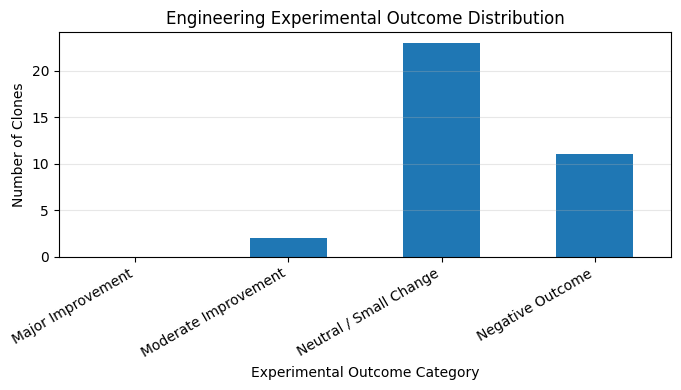

In [32]:
result_order = [
    "Major Improvement",
    "Moderate Improvement",
    "Neutral / Small Change",
    "Negative Outcome",
]

result_counts = (
    work["engineering_result_class"]
    .value_counts()
    .reindex(result_order, fill_value=0)
)

display(result_counts)

result_counts.plot.bar(figsize=(7, 4))

plt.title("Engineering Experimental Outcome Distribution")
plt.xlabel("Experimental Outcome Category")
plt.ylabel("Number of Clones")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Section 12 — Before vs after titer analysis

Each point represents one engineered clone.

The x-axis shows baseline titer.

The y-axis shows post-engineering titer.

Points above the diagonal improved after engineering.

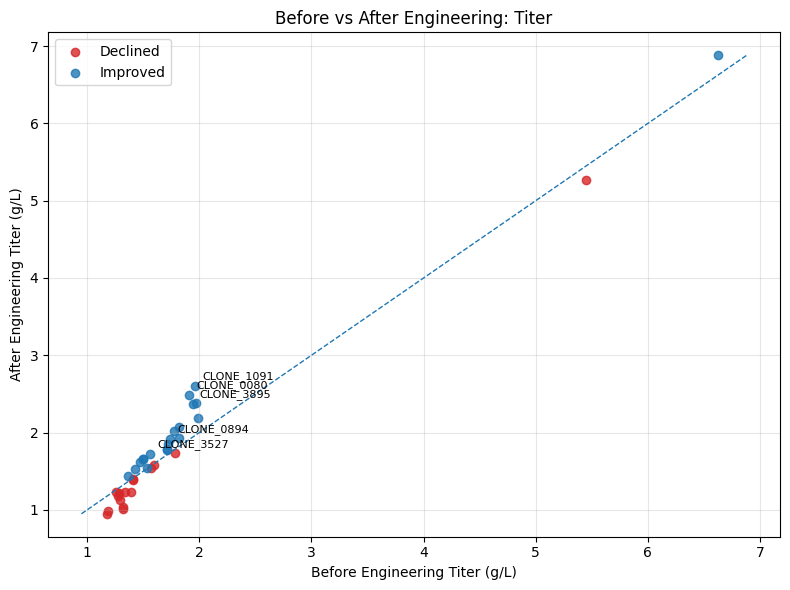

In [33]:
plot_df = work.copy()

plot_df["titer_response"] = np.where(
    plot_df["titer_after_g_L"] >= plot_df["titer_before_g_L"],
    "Improved",
    "Declined",
)

color_map = {
    "Improved": "tab:blue",
    "Declined": "tab:red",
}

plt.figure(figsize=(8, 6))

for label, group in plot_df.groupby("titer_response"):
    plt.scatter(
        group["titer_before_g_L"],
        group["titer_after_g_L"],
        label=label,
        alpha=0.8,
        c=color_map[label],
    )

min_val = min(
    plot_df["titer_before_g_L"].min(),
    plot_df["titer_after_g_L"].min(),
)

max_val = max(
    plot_df["titer_before_g_L"].max(),
    plot_df["titer_after_g_L"].max(),
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1,
)

for _, row in plot_df.sort_values("experimental_roi_score", ascending=False).head(5).iterrows():
    plt.annotate(
        row["clone_id"],
        (
            row["titer_before_g_L"],
            row["titer_after_g_L"],
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Before vs After Engineering: Titer")
plt.xlabel("Before Engineering Titer (g/L)")
plt.ylabel("After Engineering Titer (g/L)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 13 — Before vs after qP analysis

Specific productivity, or qP, measures protein production per cell.

This plot checks whether engineering improved per-cell productivity.

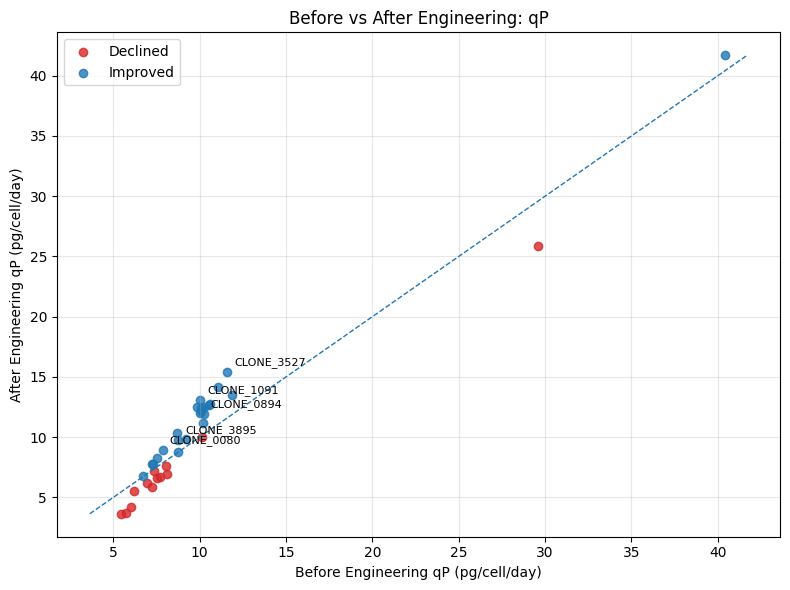

In [34]:
plot_df = work.copy()

plot_df["qp_response"] = np.where(
    plot_df["qp_after_pg_cell_day"] >= plot_df["qp_before_pg_cell_day"],
    "Improved",
    "Declined",
)

color_map = {
    "Improved": "tab:blue",
    "Declined": "tab:red",
}

plt.figure(figsize=(8, 6))

for label, group in plot_df.groupby("qp_response"):
    plt.scatter(
        group["qp_before_pg_cell_day"],
        group["qp_after_pg_cell_day"],
        label=label,
        alpha=0.8,
        c=color_map[label],
    )

min_val = min(
    plot_df["qp_before_pg_cell_day"].min(),
    plot_df["qp_after_pg_cell_day"].min(),
)

max_val = max(
    plot_df["qp_before_pg_cell_day"].max(),
    plot_df["qp_after_pg_cell_day"].max(),
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1,
)

for _, row in plot_df.sort_values("experimental_roi_score", ascending=False).head(5).iterrows():
    plt.annotate(
        row["clone_id"],
        (
            row["qp_before_pg_cell_day"],
            row["qp_after_pg_cell_day"],
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Before vs After Engineering: qP")
plt.xlabel("Before Engineering qP (pg/cell/day)")
plt.ylabel("After Engineering qP (pg/cell/day)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 14 — Before vs after stability analysis

Stability is important because unstable clones can fail during scale-up or long-term manufacturing.

This plot shows whether engineering improved clone stability.

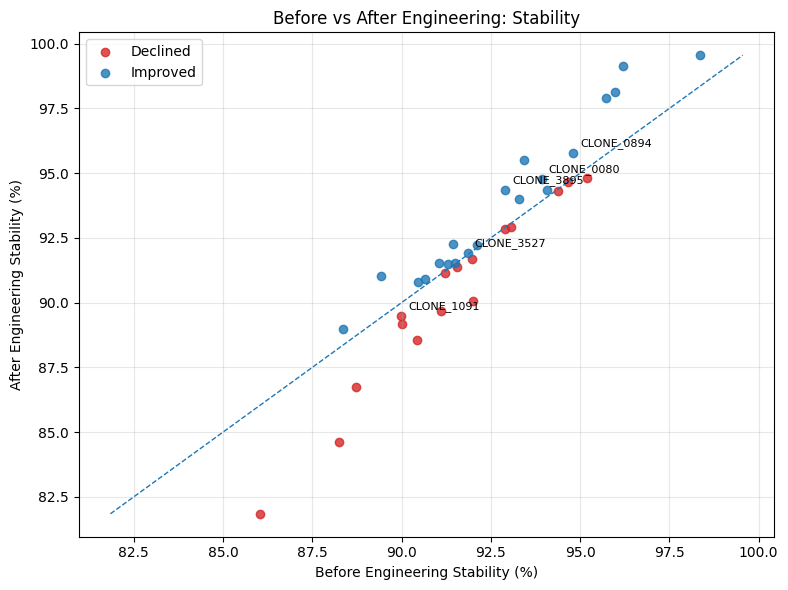

In [35]:
plot_df = work.copy()

plot_df["stability_response"] = np.where(
    plot_df["stability_after_pct"] >= plot_df["stability_before_pct"],
    "Improved",
    "Declined",
)

color_map = {
    "Improved": "tab:blue",
    "Declined": "tab:red",
}

plt.figure(figsize=(8, 6))

for label, group in plot_df.groupby("stability_response"):
    plt.scatter(
        group["stability_before_pct"],
        group["stability_after_pct"],
        label=label,
        alpha=0.8,
        c=color_map[label],
    )

min_val = min(
    plot_df["stability_before_pct"].min(),
    plot_df["stability_after_pct"].min(),
)

max_val = max(
    plot_df["stability_before_pct"].max(),
    plot_df["stability_after_pct"].max(),
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1,
)

for _, row in plot_df.sort_values("experimental_roi_score", ascending=False).head(5).iterrows():
    plt.annotate(
        row["clone_id"],
        (
            row["stability_before_pct"],
            row["stability_after_pct"],
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Before vs After Engineering: Stability")
plt.xlabel("Before Engineering Stability (%)")
plt.ylabel("After Engineering Stability (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 15 — Before vs after quality analysis

Quality reflects product-related performance.

In this synthetic project, quality represents a combined quality index.

Higher values indicate better expected product quality.

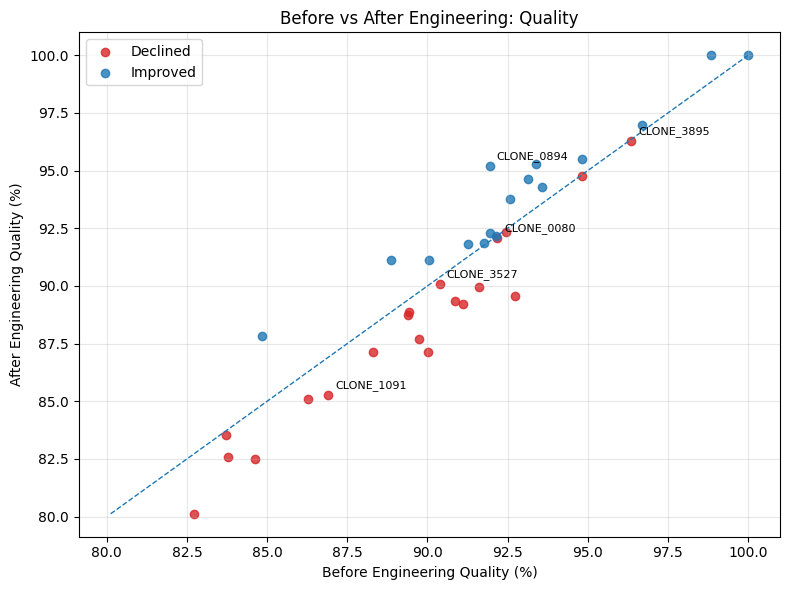

In [36]:
plot_df = work.copy()

plot_df["quality_response"] = np.where(
    plot_df["quality_after_pct"] >= plot_df["quality_before_pct"],
    "Improved",
    "Declined",
)

color_map = {
    "Improved": "tab:blue",
    "Declined": "tab:red",
}

plt.figure(figsize=(8, 6))

for label, group in plot_df.groupby("quality_response"):
    plt.scatter(
        group["quality_before_pct"],
        group["quality_after_pct"],
        label=label,
        alpha=0.8,
        c=color_map[label],
    )

min_val = min(
    plot_df["quality_before_pct"].min(),
    plot_df["quality_after_pct"].min(),
)

max_val = max(
    plot_df["quality_before_pct"].max(),
    plot_df["quality_after_pct"].max(),
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1,
)

for _, row in plot_df.sort_values("experimental_roi_score", ascending=False).head(5).iterrows():
    plt.annotate(
        row["clone_id"],
        (
            row["quality_before_pct"],
            row["quality_after_pct"],
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Before vs After Engineering: Quality")
plt.xlabel("Before Engineering Quality (%)")
plt.ylabel("After Engineering Quality (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 16 — Engineering response diversity

Different clones can respond differently to the same intervention.

This section summarizes observed ROI by recommended intervention.

It helps determine whether a strategy is broadly useful or only useful for specific clones.

In [37]:
response_summary = (
    work
    .groupby("recommended_intervention")
    [
        [
            "experimental_roi_score",
            "delta_titer_g_L",
            "delta_qp_pg_cell_day",
            "delta_stability_pct",
            "delta_quality_pct",
        ]
    ]
    .mean()
    .round(3)
)

display(response_summary)

,experimental_roi_score,delta_titer_g_L,delta_qp_pg_cell_day,delta_stability_pct,delta_quality_pct
recommended_intervention,,,,,
PDI_folding_support,-1.850,0.042,-1.227,0.822,0.187
XBP1s_secretory_support,-0.485,0.069,0.692,0.003,-0.219


## Section 17 — Top successful engineering projects

This section ranks the best observed engineering outcomes.

These projects represent the strongest simulated success cases.

In [38]:
top_success = (
    work
    .sort_values("experimental_roi_score", ascending=False)
    .copy()
)

display(
    top_success[
        [
            "clone_id",
            "recommended_intervention",
            "experimental_outcome",
            "engineering_result_class",
            "titer_before_g_L",
            "titer_after_g_L",
            "qp_before_pg_cell_day",
            "qp_after_pg_cell_day",
            "stability_before_pct",
            "stability_after_pct",
            "quality_before_pct",
            "quality_after_pct",
            "experimental_roi_score",
        ]
    ].head(15)
)

,clone_id,recommended_intervention,experimental_outcome,engineering_result_class,titer_before_g_L,titer_after_g_L,qp_before_pg_cell_day,qp_after_pg_cell_day,stability_before_pct,stability_after_pct,quality_before_pct,quality_after_pct,experimental_roi_score
31,CLONE_1091,XBP1s_secretory_support,strong_success,Moderate Improvement,1.965808,2.602630,10.024591,13.088714,89.982346,89.478931,86.904153,85.257857,4.995627
6,CLONE_0080,XBP1s_secretory_support,strong_success,Moderate Improvement,1.909606,2.484200,7.863439,8.912731,93.930922,94.768563,92.180047,92.091506,4.013603
3,CLONE_3895,XBP1s_secretory_support,partial_success,Neutral / Small Change,1.939276,2.370905,8.768242,9.725536,92.905443,94.338296,96.362190,96.272419,2.963176
17,CLONE_0894,XBP1s_secretory_support,partial_success,Neutral / Small Change,1.738660,1.915392,10.247983,11.939220,94.803695,95.773596,91.944187,95.179871,2.079992
29,CLONE_3527,XBP1s_secretory_support,strong_success,Neutral / Small Change,1.562892,1.716325,11.581697,15.417011,91.857272,91.926304,90.383678,90.100586,2.075138
32,CLONE_1437,XBP1s_secretory_support,strong_success,Neutral / Small Change,1.776534,2.014555,10.514688,12.692175,91.058075,91.516147,91.255422,91.796612,2.060476
0,CLONE_4625,PDI_folding_support,partial_success,Neutral / Small Change,6.624179,6.882502,40.417727,41.701048,91.493167,91.539428,84.852174,87.838499,1.894724
4,CLONE_3895,XBP1s_secretory_support,strong_success,Neutral / Small Change,1.499980,1.656397,9.851452,12.491053,91.435732,92.266302,96.685412,96.975757,1.715323
22,CLONE_0834,XBP1s_secretory_support,strong_success,Neutral / Small Change,1.816022,2.075599,10.577022,12.718644,92.106204,92.218042,84.613616,82.487621,1.458047
20,CLONE_4425,XBP1s_secretory_support,partial_success,Neutral / Small Change,1.966028,2.387933,6.959108,6.225694,90.019154,89.166074,91.763511,91.862988,1.346788


## Section 18 — Experimental outcome scorecard

This scorecard summarizes the simulated engineering experiment campaign.

It provides a compact executive view of engineering performance.

In [39]:
scorecard = pd.DataFrame(
    {
        "metric": [
            "engineering_experiments",
            "mean_delta_titer_g_L",
            "mean_delta_qp_pg_cell_day",
            "mean_delta_stability_pct",
            "mean_delta_quality_pct",
            "mean_experimental_roi_score",
            "major_improvement_count",
            "negative_outcome_count",
        ],
        "value": [
            len(work),
            round(work["delta_titer_g_L"].mean(), 3),
            round(work["delta_qp_pg_cell_day"].mean(), 3),
            round(work["delta_stability_pct"].mean(), 3),
            round(work["delta_quality_pct"].mean(), 3),
            round(work["experimental_roi_score"].mean(), 3),
            int((work["engineering_result_class"] == "Major Improvement").sum()),
            int((work["engineering_result_class"] == "Negative Outcome").sum()),
        ],
    }
)

display(scorecard)

,metric,value
0,engineering_experiments,36.000
1,mean_delta_titer_g_L,0.068
2,mean_delta_qp_pg_cell_day,0.586
3,mean_delta_stability_pct,0.049
4,mean_delta_quality_pct,-0.197
5,mean_experimental_roi_score,-0.560
6,major_improvement_count,0.000
7,negative_outcome_count,11.000


## Section 18b — Executive engineering outcome table

This table summarizes each engineered clone in scientist-facing terms.

It is designed for future dashboards, CDMO communication, and investor-facing summaries.

The table reports before/after titer, qP, stability, quality, engineering gain, and ROI.

In [40]:
executive_outcome_table = (
    work[
        [
            "clone_id",
            "recommended_intervention",
            "experimental_outcome",
            "engineering_result_class",
            "titer_before_g_L",
            "titer_after_g_L",
            "delta_titer_g_L",
            "qp_before_pg_cell_day",
            "qp_after_pg_cell_day",
            "delta_qp_pg_cell_day",
            "stability_before_pct",
            "stability_after_pct",
            "delta_stability_pct",
            "quality_before_pct",
            "quality_after_pct",
            "delta_quality_pct",
            "engineering_gain",
            "realized_gain",
            "experimental_roi_score",
        ]
    ]
    .sort_values("experimental_roi_score", ascending=False)
    .round(3)
)

display(executive_outcome_table.head(20))

,clone_id,recommended_intervention,experimental_outcome,engineering_result_class,titer_before_g_L,titer_after_g_L,delta_titer_g_L,qp_before_pg_cell_day,qp_after_pg_cell_day,delta_qp_pg_cell_day,stability_before_pct,stability_after_pct,delta_stability_pct,quality_before_pct,quality_after_pct,delta_quality_pct,engineering_gain,realized_gain,experimental_roi_score
31,CLONE_1091,XBP1s_secretory_support,strong_success,Moderate Improvement,1.966,2.603,0.637,10.025,13.089,3.064,89.982,89.479,-0.503,86.904,85.258,-1.646,20.205,20.205,4.996
6,CLONE_0080,XBP1s_secretory_support,strong_success,Moderate Improvement,1.910,2.484,0.575,7.863,8.913,1.049,93.931,94.769,0.838,92.180,92.092,-0.089,19.658,19.658,4.014
3,CLONE_3895,XBP1s_secretory_support,partial_success,Neutral / Small Change,1.939,2.371,0.432,8.768,9.726,0.957,92.905,94.338,1.433,96.362,96.272,-0.090,19.546,19.546,2.963
17,CLONE_0894,XBP1s_secretory_support,partial_success,Neutral / Small Change,1.739,1.915,0.177,10.248,11.939,1.691,94.804,95.774,0.970,91.944,95.180,3.236,17.128,17.128,2.080
29,CLONE_3527,XBP1s_secretory_support,strong_success,Neutral / Small Change,1.563,1.716,0.153,11.582,15.417,3.835,91.857,91.926,0.069,90.384,90.101,-0.283,15.917,15.917,2.075
32,CLONE_1437,XBP1s_secretory_support,strong_success,Neutral / Small Change,1.777,2.015,0.238,10.515,12.692,2.177,91.058,91.516,0.458,91.255,91.797,0.541,16.473,16.473,2.060
0,CLONE_4625,PDI_folding_support,partial_success,Neutral / Small Change,6.624,6.883,0.258,40.418,41.701,1.283,91.493,91.539,0.046,84.852,87.838,2.986,15.993,15.993,1.895
4,CLONE_3895,XBP1s_secretory_support,strong_success,Neutral / Small Change,1.500,1.656,0.156,9.851,12.491,2.640,91.436,92.266,0.831,96.685,96.976,0.290,16.032,16.032,1.715
22,CLONE_0834,XBP1s_secretory_support,strong_success,Neutral / Small Change,1.816,2.076,0.260,10.577,12.719,2.142,92.106,92.218,0.112,84.614,82.488,-2.126,16.635,16.635,1.458
20,CLONE_4425,XBP1s_secretory_support,partial_success,Neutral / Small Change,1.966,2.388,0.422,6.959,6.226,-0.733,90.019,89.166,-0.853,91.764,91.863,0.099,19.431,19.431,1.347


## Section 18c — Portfolio-level ROI summary

Clone-level ROI asks whether one intervention improved one clone.

Portfolio-level ROI asks whether the entire platform improves development efficiency.

This section estimates whether AI-guided engineering creates value at the CLD program level by summarizing:

- number of improved clones
- number of major/moderate improvements
- average titer gain
- average quality gain
- estimated avoided low-value engineering experiments

In [41]:
portfolio_roi_summary = pd.DataFrame(
    {
        "metric": [
            "total_engineering_projects",
            "major_or_moderate_improvements",
            "negative_outcomes",
            "mean_titer_gain_g_L",
            "mean_qp_gain_pg_cell_day",
            "mean_stability_gain_pct",
            "mean_quality_gain_pct",
            "mean_experimental_roi_score",
            "estimated_useful_project_rate",
        ],
        "value": [
            len(work),
            int(
                work["engineering_result_class"]
                .isin(["Major Improvement", "Moderate Improvement"])
                .sum()
            ),
            int((work["engineering_result_class"] == "Negative Outcome").sum()),
            round(work["delta_titer_g_L"].mean(), 3),
            round(work["delta_qp_pg_cell_day"].mean(), 3),
            round(work["delta_stability_pct"].mean(), 3),
            round(work["delta_quality_pct"].mean(), 3),
            round(work["experimental_roi_score"].mean(), 3),
            round(
                work["engineering_result_class"]
                .isin(["Major Improvement", "Moderate Improvement"])
                .mean(),
                3,
            ),
        ],
    }
)

display(portfolio_roi_summary)

,metric,value
0,total_engineering_projects,36.000
1,major_or_moderate_improvements,2.000
2,negative_outcomes,11.000
3,mean_titer_gain_g_L,0.068
4,mean_qp_gain_pg_cell_day,0.586
5,mean_stability_gain_pct,0.049
6,mean_quality_gain_pct,-0.197
7,mean_experimental_roi_score,-0.560
8,estimated_useful_project_rate,0.056


## Section 19 — Export experimental outcome datasets

The simulated experimental outcome datasets are exported for Notebook23.

Notebook23 will use these observed outcomes to close the SDL learning loop.

In [42]:
out_dir = ROOT / "data/synthetic/digital_twin"

work.to_csv(
    out_dir / "notebook22_engineering_experimental_outcomes_5000_legacy.csv",
    index=False,
)

top_success.to_csv(
    out_dir / "notebook22_top_engineering_successes_5000_legacy.csv",
    index=False,
)

scorecard.to_csv(
    out_dir / "notebook22_experimental_outcome_scorecard_5000_legacy.csv",
    index=False,
)

executive_outcome_table.to_csv(
    out_dir / "notebook22_executive_engineering_outcome_table_5000_legacy.csv",
    index=False,
)

portfolio_roi_summary.to_csv(
    out_dir / "notebook22_portfolio_roi_summary_5000_legacy.csv",
    index=False,
)

print("Notebook22 exports saved.")

Notebook22 exports saved.


# Final Summary

Notebook22 simulated experimental outcomes after host-cell engineering interventions.

The notebook moved the project from expected engineering benefit to observed experimental behavior.

Key accomplishments:

1. Loaded Notebook21 risk-adjusted engineering recommendations
2. Created scientist-facing baseline metrics
3. Simulated intervention outcome classes
4. Generated post-engineering titer, qP, stability, and quality values
5. Calculated observed experimental gains
6. Classified engineering results
7. Ranked top successful engineering projects
8. Exported experimental outcome datasets

Notebook22 is important because it creates simulated test results that can be fed back into the SDL loop.

The platform now supports:

Prediction → Selection → Engineering Recommendation → Risk Assessment → Experimental Outcome Simulation

This brings the project close to a full digital Design-Build-Test-Learn prototype.

# References

## Cell Line Development and CHO Biology

Wurm FM.  
Production of recombinant protein therapeutics in cultivated mammalian cells.  
Nature Biotechnology, 2004.  
DOI: 10.1038/nbt1026

Kim JY, Kim YG, Lee GM.  
CHO cells in biotechnology for production of recombinant proteins.  
Current Opinion in Biotechnology, 2012.  
DOI: 10.1016/j.copbio.2011.10.002

## CHO Engineering and Synthetic Biology

Galbraith DJ, Tait AS, Racher AJ, Birch JR, James DC.  
Application of synthetic biology to mammalian cell engineering.  
Current Opinion in Chemical Engineering, 2018.

Fischer S, Handrick R, Otte K.  
The art of CHO cell engineering: A comprehensive retrospect and future perspectives.  
Biotechnology Advances, 2015.

## CRISPR and Genome Engineering

Doudna JA, Charpentier E.  
The new frontier of genome engineering with CRISPR-Cas9.  
Science, 2014.  
DOI: 10.1126/science.1258096

## Self-Driving Laboratories and Active Learning

MacLeod BP et al.  
Self-driving laboratory for accelerated discovery of thin-film materials.  
Science Advances, 2020.  
DOI: 10.1126/sciadv.aaz8867

Lookman T, Balachandran PV, Xue D, Yuan R.  
Active learning in materials science with emphasis on adaptive sampling using uncertainties for targeted design.  
npj Computational Materials, 2019.  
DOI: 10.1038/s41524-019-0153-6

## Digital Twins and PAT

Narciso-da-Rocha C et al.  
Digital twins in biopharmaceutical manufacturing.  
Biotechnology Advances, 2024.  
DOI: 10.1016/j.biotechadv.2024.108388

FDA.  
PAT — A Framework for Innovative Pharmaceutical Development, Manufacturing, and Quality Assurance.  
2004.